# BettingRisks — Match Outcome Modeling

This project builds a machine-learning pipeline that estimates the probability of football match outcomes (home win / draw / away win) and can be used as an input to a betting-risk evaluation system.

The notebook walks through:
1. data collection from Football-Data.co.uk,
2. cleaning, outlier handling and feature engineering,
3. exploratory analysis and hypothesis testing,
4. training and tuning four classical models (Logistic Regression, KNN, Decision Tree, Random Forest),
5. comparison and selection of the best model.




The goal is not deterministic prediction but **probability estimation** for three events (H/D/A), to be compared against bookmaker odds for risk assessment. This is therefore a **multi-class classification** problem with three classes and a known imbalance (draws are less frequent).


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Data Collection

Source: **football-data.co.uk** — historical CSV files per league/season.
We pull 10 recent seasons across 4 top European leagues (EPL, La Liga, Bundesliga, Serie A) so that the model is trained on a large but temporally relevant sample.


Using 10 recent seasons across 4 leagues gives ~15-20k matches — enough for classical ML while staying representative of modern playing style and bookmaker pricing.


In [2]:
LEAGUES = [
    ("Premier League", "england", "E0"),
    ("La Liga",        "spain",   "SP1"),
    ("Bundesliga",     "germany", "D1"),
    ("Serie A",        "italy",   "I1"),
]
SEASONS = [
    ("2015/16", "1516"), ("2016/17", "1617"), ("2017/18", "1718"),
    ("2018/19", "1819"), ("2019/20", "1920"), ("2020/21", "2021"),
    ("2021/22", "2122"), ("2022/23", "2223"), ("2023/24", "2324"),
    ("2024/25", "2425"),
]

BASE_URL = "https://www.football-data.co.uk/mmz4281"
all_dfs = []

for league_name, country, league_code in LEAGUES:
    for season_name, season_code in SEASONS:
        url = f"{BASE_URL}/{season_code}/{league_code}.csv"
        try:
            df_temp = pd.read_csv(url)
            df_temp["League"] = league_name
            df_temp["Season"] = season_name
            all_dfs.append(df_temp)
            print(f"OK  {league_name} {season_name}")
        except Exception:
            print(f"--  {league_name} {season_name} (not found)")

df_raw = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal records: {len(df_raw)}")
print(f"Total columns: {df_raw.shape[1]}")


OK  Premier League 2015/16
OK  Premier League 2016/17
OK  Premier League 2017/18
OK  Premier League 2018/19
OK  Premier League 2019/20
OK  Premier League 2020/21
OK  Premier League 2021/22
OK  Premier League 2022/23
OK  Premier League 2023/24
OK  Premier League 2024/25
OK  La Liga 2015/16
OK  La Liga 2016/17
OK  La Liga 2017/18
OK  La Liga 2018/19
OK  La Liga 2019/20
OK  La Liga 2020/21
OK  La Liga 2021/22
OK  La Liga 2022/23
OK  La Liga 2023/24
OK  La Liga 2024/25
OK  Bundesliga 2015/16
OK  Bundesliga 2016/17
OK  Bundesliga 2017/18
OK  Bundesliga 2018/19
OK  Bundesliga 2019/20
OK  Bundesliga 2020/21
OK  Bundesliga 2021/22
OK  Bundesliga 2022/23
OK  Bundesliga 2023/24
OK  Bundesliga 2024/25
OK  Serie A 2015/16
OK  Serie A 2016/17
OK  Serie A 2017/18
OK  Serie A 2018/19
OK  Serie A 2019/20
OK  Serie A 2020/21
OK  Serie A 2021/22
OK  Serie A 2022/23
OK  Serie A 2023/24
OK  Serie A 2024/25

Total records: 14461
Total columns: 155


## 3. Feature Selection

The raw file contains 100+ columns (odds from many bookmakers, exotic markets, statistics). We keep a small, interpretable subset.


In [3]:
optimal_cols = [
    "Date", "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR",        # Full-time (TARGET source)
    "HTHG", "HTAG", "HTR",        # Half-time
    "HS", "AS",                   # Shots
    "HST", "AST",                 # Shots on target
    "HC", "AC",                   # Corners
    "HF", "AF",                   # Fouls
    "HY", "AY",                   # Yellow cards
    "HR", "AR",                   # Red cards
    "B365H", "B365D", "B365A",    # Bet365 pre-match odds
    "League", "Season",
]

df = df_raw[[c for c in optimal_cols if c in df_raw.columns]].copy()
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (14461, 26)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AF,HY,AY,HR,AR,B365H,B365D,B365A,League,Season
0,08/08/2015,Bournemouth,Aston Villa,0.0,1.0,A,0.0,0.0,D,11.0,...,13.0,3.0,4.0,0.0,0.0,2.00,3.6,4.00,Premier League,2015/16
1,08/08/2015,Chelsea,Swansea,2.0,2.0,D,2.0,1.0,H,11.0,...,16.0,1.0,3.0,1.0,0.0,1.36,5.0,11.00,Premier League,2015/16
2,08/08/2015,Everton,Watford,2.0,2.0,D,0.0,1.0,A,10.0,...,13.0,1.0,2.0,0.0,0.0,1.70,3.9,5.50,Premier League,2015/16
3,08/08/2015,Leicester,Sunderland,4.0,2.0,H,3.0,0.0,H,19.0,...,17.0,2.0,4.0,0.0,0.0,1.95,3.5,4.33,Premier League,2015/16
4,08/08/2015,Man United,Tottenham,1.0,0.0,H,1.0,0.0,H,9.0,...,12.0,2.0,3.0,0.0,0.0,1.65,4.0,6.00,Premier League,2015/16


### Why these columns?

We grouped them by purpose:

* **Match metadata** (Date, League, Season, HomeTeam, AwayTeam) — for time-aware analysis and team-specific behaviour.
* **Outcome** (FTHG, FTAG, FTR) — used to *build* the target. They will not be used as predictors.
* **Half-time stats** (HTHG, HTAG, HTR) — describe early dynamics; later treated as in-game features.
* **Match statistics** (HS, AS, HST, AST, HC, AC, HF, AF, HY, AY, HR, AR) — capture playing style, dominance and discipline.
* **Bookmaker odds** (B365H/D/A) — the only **truly pre-match** numerical signal. They embed market expectations and are critical for a betting-risk system.

We drop other bookmakers' odds and exotic markets to avoid redundancy and reduce overfitting.



## ⚠️ Important note on data leakage

**Post-match statistics** (HS, AS, HST, AST, HC, AC, HF, AF, HY, AY, HR, AR, HTHG, HTAG, HTR) are only known *after* the match has been played. If the goal is to predict the outcome **before kick-off** (which is what real betting requires), using these features is a leakage of future information into the training data — the model will look very accurate but cannot be deployed for real betting.

In this notebook we intentionally include them because the project is also an *exploratory ML exercise* — we want to see which in-game patterns separate the three outcomes. We label this clearly. A production-grade pre-match model would keep only `Date, HomeTeam, AwayTeam, League, Season, B365H, B365D, B365A` plus engineered rolling form features.


## 4. Data Cleaning

### 4.1 Missing values

We first quantify missingness, then drop rows with any NaN — the dataset is large enough that this is acceptable, and the proportion of rows with missing odds/stats is small.


In [4]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = (pd.DataFrame({"Column": missing_values.index,
                            "Missing_Count": missing_values.values,
                            "Missing_Percent": missing_percent.values})
              .sort_values("Missing_Percent", ascending=False))
print("Missing values:")
print(missing_df[missing_df["Missing_Count"] > 0])

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"\nRows after dropna: {df.shape[0]} (removed {before - df.shape[0]})")


Missing values:
      Column  Missing_Count  Missing_Percent
23     B365A              4         0.027661
22     B365D              4         0.027661
21     B365H              4         0.027661
6       HTHG              3         0.020745
8        HTR              3         0.020745
7       HTAG              3         0.020745
10        AS              2         0.013830
9         HS              2         0.013830
11       HST              2         0.013830
14        AC              2         0.013830
17        HY              2         0.013830
16        AF              2         0.013830
15        HF              2         0.013830
18        AY              2         0.013830
20        AR              2         0.013830
19        HR              2         0.013830
12       AST              2         0.013830
13        HC              2         0.013830
2   AwayTeam              1         0.006915
3       FTHG              1         0.006915
4       FTAG              1         0.0

### 4.2 Duplicates

In [5]:
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")
if dups:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after de-dup: {df.shape}")


Duplicate rows: 0


### 4.3 Outliers — IQR detection + clipping

We use the **Interquartile Range (IQR)** rule: a value is an outlier if it falls below `Q1 − 1.5·IQR` or above `Q3 + 1.5·IQR`.

Instead of *deleting* outliers we **clip (winsorize)** the most affected columns to a sensible upper bound. Reason: extreme odds (e.g. 50.0) and very high shot counts are real but rare; clipping caps their leverage on linear models without losing the row.



In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_indices = set()
outlier_report = {}

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    out = df[(df[col] < lo) | (df[col] > hi)].index
    outlier_indices.update(out)
    if len(out) > 0:
        outlier_report[col] = len(out)

print(f"Total unique rows containing at least one outlier: {len(outlier_indices)}")
print("\nTop 10 columns by outlier count:")
for col, count in sorted(outlier_report.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {col}: {count}")


Total unique rows containing at least one outlier: 6355

Top 10 columns by outlier count:
  B365D: 1436
  AR: 1385
  B365H: 1246
  B365A: 1210
  FTHG: 1188
  HR: 1143
  HTHG: 510
  HST: 489
  AC: 360
  AST: 348


In [7]:
clip_caps = {
    "B365H": 15, "B365D": 10, "B365A": 20,
    "HC": 20, "AC": 15,
    "HS": 35, "AS": 30,
    "HST": 15, "AST": 15,
}
for col, cap in clip_caps.items():
    if col in df.columns:
        df[col] = df[col].clip(upper=cap)

print("Clipping applied. New summary stats:")
print(df[list(clip_caps)].describe().round(2))


Clipping applied. New summary stats:
          B365H     B365D     B365A        HC        AC        HS        AS  \
count  14455.00  14455.00  14455.00  14455.00  14455.00  14455.00  14455.00   
mean       2.81      4.11      4.55      5.46      4.45     13.58     11.13   
std        1.98      1.27      3.63      2.99      2.62      5.34      4.74   
min        1.02      2.40      1.07      0.00      0.00      0.00      0.00   
25%        1.66      3.40      2.30      3.00      3.00     10.00      8.00   
50%        2.20      3.60      3.30      5.00      4.00     13.00     11.00   
75%        3.10      4.33      5.25      7.00      6.00     17.00     14.00   
max       15.00     10.00     20.00     20.00     15.00     35.00     30.00   

            HST       AST  
count  14455.00  14455.00  
mean       4.89      4.02  
std        2.64      2.36  
min        0.00      0.00  
25%        3.00      2.00  
50%        5.00      4.00  
75%        6.00      5.00  
max       15.00     15.00  

## 5. Target Variable & Feature Engineering

### 5.1 Target

`FTR` is a 3-level categorical variable {H, D, A}. We encode it as integers `H→1, D→0, A→2`-style via `LabelEncoder` to use it with sklearn classifiers.



In [8]:
# Drop very-low-information columns (red cards are rare and noisy;
# half-time goals are partly redundant with FTR-related dynamics).
df = df.drop(columns=["HR", "AR", "HTHG", "HTAG"], errors="ignore")

le_target = LabelEncoder()
df["target"] = le_target.fit_transform(df["FTR"])

print("Target encoding:",
      dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print("\nTarget distribution:")
for cls in le_target.classes_:
    code_ = le_target.transform([cls])[0]
    cnt = (df["target"] == code_).sum()
    print(f"  {cls} (={code_}): {cnt}  ({cnt/len(df)*100:.2f}%)")


Target encoding: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}

Target distribution:
  A (=0): 4463  (30.88%)
  D (=1): 3602  (24.92%)
  H (=2): 6390  (44.21%)


### 5.2 Date and team features

In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True, errors="coerce")
df["year"]      = df["Date"].dt.year
df["month"]     = df["Date"].dt.month
df["dayofweek"] = df["Date"].dt.dayofweek

# Encode teams with a single shared LabelEncoder (so 'Arsenal' has the same id
# whether it appears as Home or Away).
teams = pd.concat([df["HomeTeam"], df["AwayTeam"]]).unique()
le_team = LabelEncoder().fit(teams)
df["HomeTeam_enc"] = le_team.transform(df["HomeTeam"])
df["AwayTeam_enc"] = le_team.transform(df["AwayTeam"])

print("Date features and team encodings created.")


Date features and team encodings created.


### 5.3 Build feature matrix X and target y

We build `X` by:
1. dropping the leakage columns derived from the outcome (`FTR`, `FTHG`, `FTAG`, `HTR`, `target`, `Date`),
2. dropping the raw text team columns (we already have integer encodings),
3. one-hot encoding `League` and `Season`,
4. adding **engineered features** that summarize the betting-market signal.




In [10]:
y = df["target"].copy()

drop_cols = ["FTR", "FTHG", "FTAG", "HTR", "target", "Date",
             "HomeTeam", "AwayTeam"]   # raw text team names already encoded
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

# One-hot encode League and Season (low cardinality)
X = pd.get_dummies(X, columns=[c for c in ["League", "Season"] if c in X.columns],
                   drop_first=True)

# Engineered features from the betting odds
X["odds_diff"]      = df["B365H"] - df["B365A"]
X["odds_ratio"]     = df["B365H"] / (df["B365A"] + 1e-3)
X["total_odds"]     = df["B365H"] + df["B365D"] + df["B365A"]
X["home_advantage"] = (df["HS"] - df["AS"]) / (df["HS"] + df["AS"] + 1e-3)

# Drop near-duplicate features (>0.95 correlation) to reduce multicollinearity
X_numeric = X.select_dtypes(include=[np.number])
corr = X_numeric.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
if to_drop:
    print("Dropping highly-correlated columns:", to_drop)
    X = X.drop(columns=to_drop)

print(f"Final feature matrix: {X.shape}")
print("Feature list:", X.columns.tolist())


Dropping highly-correlated columns: ['odds_ratio', 'total_odds']
Final feature matrix: (14455, 32)
Feature list: ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'B365H', 'B365D', 'B365A', 'year', 'month', 'dayofweek', 'HomeTeam_enc', 'AwayTeam_enc', 'League_La Liga', 'League_Premier League', 'League_Serie A', 'Season_2016/17', 'Season_2017/18', 'Season_2018/19', 'Season_2019/20', 'Season_2020/21', 'Season_2021/22', 'Season_2022/23', 'Season_2023/24', 'Season_2024/25', 'odds_diff', 'home_advantage']


## 6. Exploratory Data Analysis

### 6.1 Dataset overview

In [11]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total records: {len(X)}")
print(f"Total features: {X.shape[1]}")

target_counts = pd.Series(y).value_counts().sort_index()
inv = {v: k for k, v in zip(le_target.classes_, le_target.transform(le_target.classes_))}
label_map = {0: "Class 0", 1: "Class 1", 2: "Class 2"}
print("\nTarget distribution:")
for code_, count in target_counts.items():
    pct = count / len(y) * 100
    print(f"  {inv.get(code_, code_)} (={code_}): {count}  ({pct:.2f}%)")

print(f"\nLeagues in dataset: {df['League'].nunique()}")
print(df['League'].value_counts())
print(f"\nSeasons in dataset: {df['Season'].nunique()}")


DATASET OVERVIEW
Total records: 14455
Total features: 32

Target distribution:
  A (=0): 4463  (30.88%)
  D (=1): 3602  (24.92%)
  H (=2): 6390  (44.21%)

Leagues in dataset: 4
League
Premier League    3800
La Liga           3800
Serie A           3796
Bundesliga        3059
Name: count, dtype: int64

Seasons in dataset: 10


### 6.2 Data quality check

In [12]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicates:    ", X.duplicated().sum())
print("\nFeature statistics (head):")
print(X.describe().round(3).T.head(15))


Missing values: 0
Duplicates:     0

Feature statistics (head):
         count      mean    std      min      25%     50%      75%     max
HS     14455.0    13.576  5.336     0.00    10.00    13.0    17.00    35.0
AS     14455.0    11.129  4.739     0.00     8.00    11.0    14.00    30.0
HST    14455.0     4.887  2.643     0.00     3.00     5.0     6.00    15.0
AST    14455.0     4.021  2.355     0.00     2.00     4.0     5.00    15.0
HC     14455.0     5.457  2.988     0.00     3.00     5.0     7.00    20.0
AC     14455.0     4.455  2.624     0.00     3.00     4.0     6.00    15.0
HF     14455.0    12.279  4.078     0.00     9.00    12.0    15.00    29.0
AF     14455.0    12.545  4.140     0.00    10.00    12.0    15.00    32.0
HY     14455.0     1.976  1.395     0.00     1.00     2.0     3.00     9.0
AY     14455.0     2.203  1.424     0.00     1.00     2.0     3.00     9.0
B365H  14455.0     2.814  1.975     1.02     1.66     2.2     3.10    15.0
B365D  14455.0     4.111  1.265     

### 6.3 Correlation analysis

We look at how raw match statistics correlate with goals scored. This is *exploratory*: it tells us which variables carry signal, not which to put in a real pre-match model.


Top correlations with FTHG (home goals):
HST    0.582
HS     0.292
HC     0.025
AY    -0.011
AF    -0.063
Name: FTHG, dtype: float64

Top correlations with FTAG (away goals):
AST    0.584
AS     0.324
HY     0.061
AC     0.043
HF    -0.024
Name: FTAG, dtype: float64


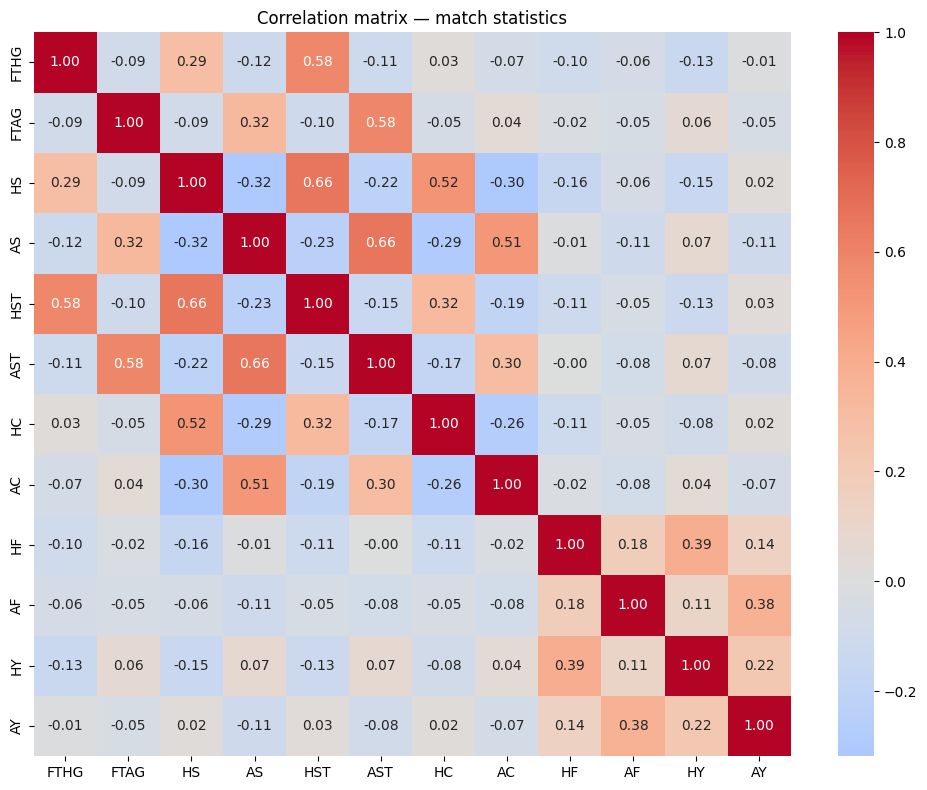

In [13]:
original_numeric = ["FTHG", "FTAG", "HS", "AS", "HST", "AST",
                    "HC", "AC", "HF", "AF", "HY", "AY"]
original_numeric = [c for c in original_numeric if c in df.columns]
correlation = df[original_numeric].corr()

print("Top correlations with FTHG (home goals):")
print(correlation["FTHG"].sort_values(ascending=False)[1:6].round(3))
print("\nTop correlations with FTAG (away goals):")
print(correlation["FTAG"].sort_values(ascending=False)[1:6].round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — match statistics")
plt.tight_layout()
plt.show()


### 6.4 Distribution of match outcomes

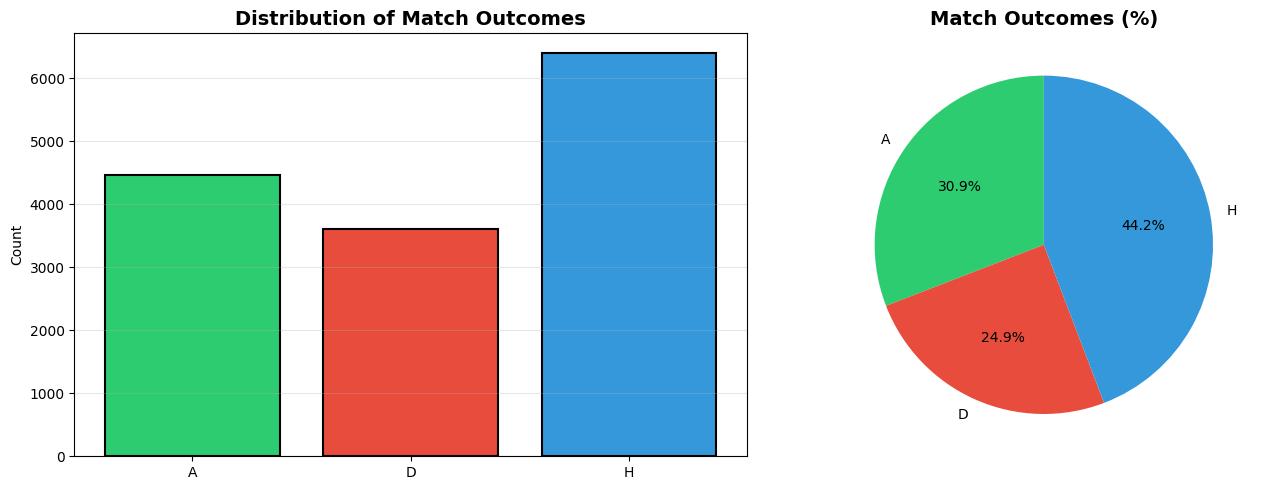

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_names = [inv.get(i, str(i)) for i in sorted(target_counts.index)]
counts = target_counts.values
colors = ["#2ecc71", "#e74c3c", "#3498db"]

axes[0].bar(target_names, counts, color=colors, edgecolor="black", linewidth=1.5)
axes[0].set_title("Distribution of Match Outcomes", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=target_names, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Match Outcomes (%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


### 6.5 Histograms of game statistics

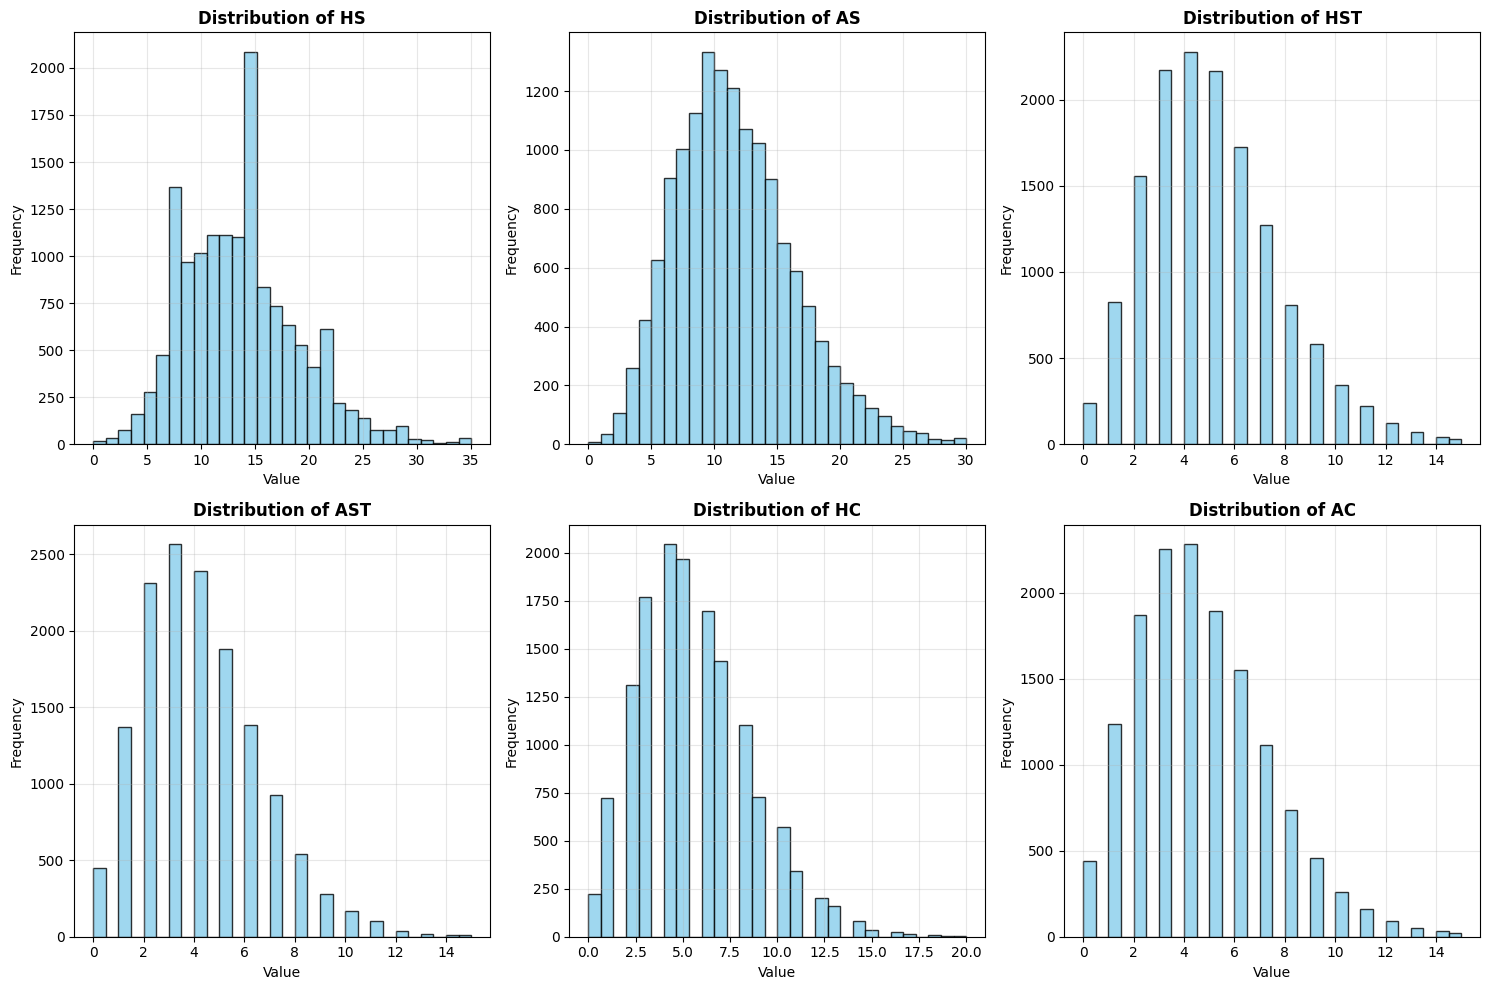

In [15]:
stats_cols = ["HS", "AS", "HST", "AST", "HC", "AC"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for idx, col in enumerate(stats_cols):
    if col in df.columns:
        axes[idx].hist(df[col], bins=30, color="skyblue", edgecolor="black", alpha=0.8)
        axes[idx].set_title(f"Distribution of {col}", fontweight="bold")
        axes[idx].set_xlabel("Value")
        axes[idx].set_ylabel("Frequency")
        axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.6 Boxplots by match outcome

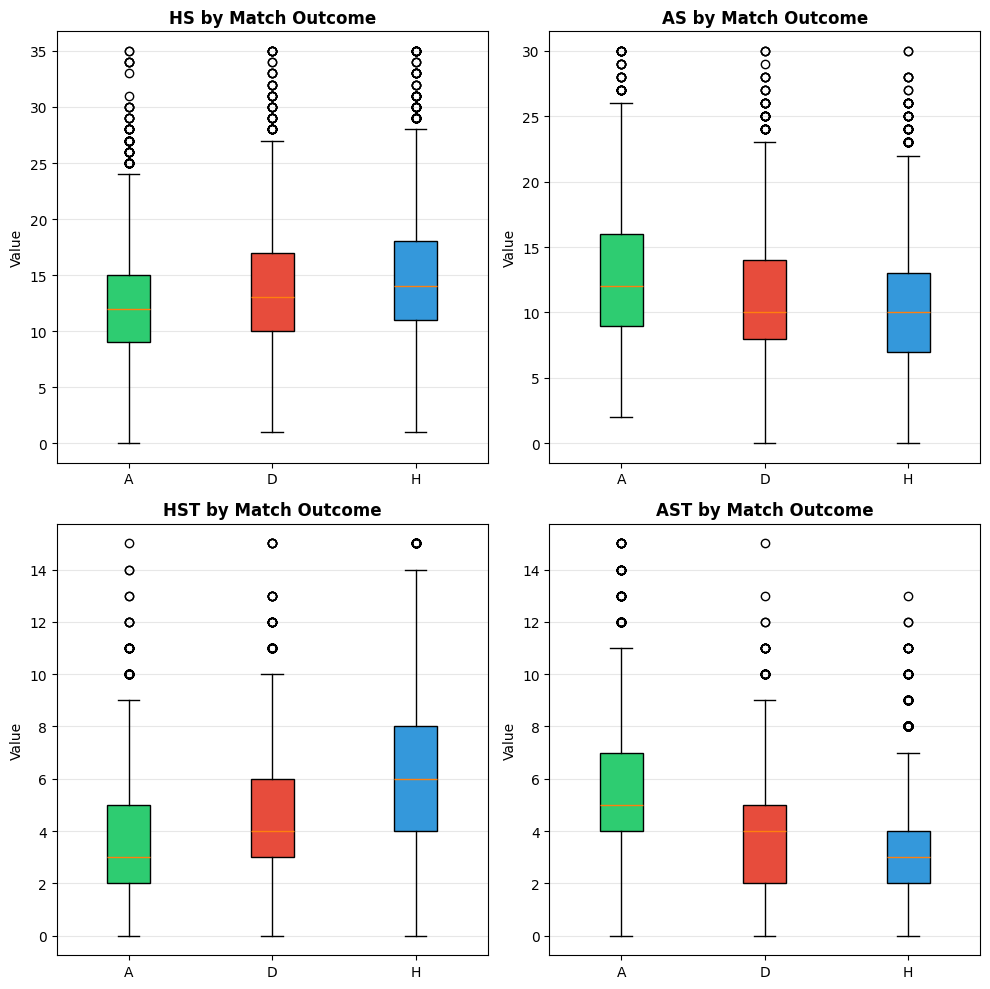

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()
plot_cols = ["HS", "AS", "HST", "AST"]
for idx, col in enumerate(plot_cols):
    if col not in df.columns:
        continue
    data_by_outcome = [df.loc[y == i, col].values for i in sorted(target_counts.index)]
    bp = axes[idx].boxplot(data_by_outcome, labels=target_names, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    axes[idx].set_title(f"{col} by Match Outcome", fontweight="bold")
    axes[idx].set_ylabel("Value")
    axes[idx].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 6.7 Shots vs Shots on Target

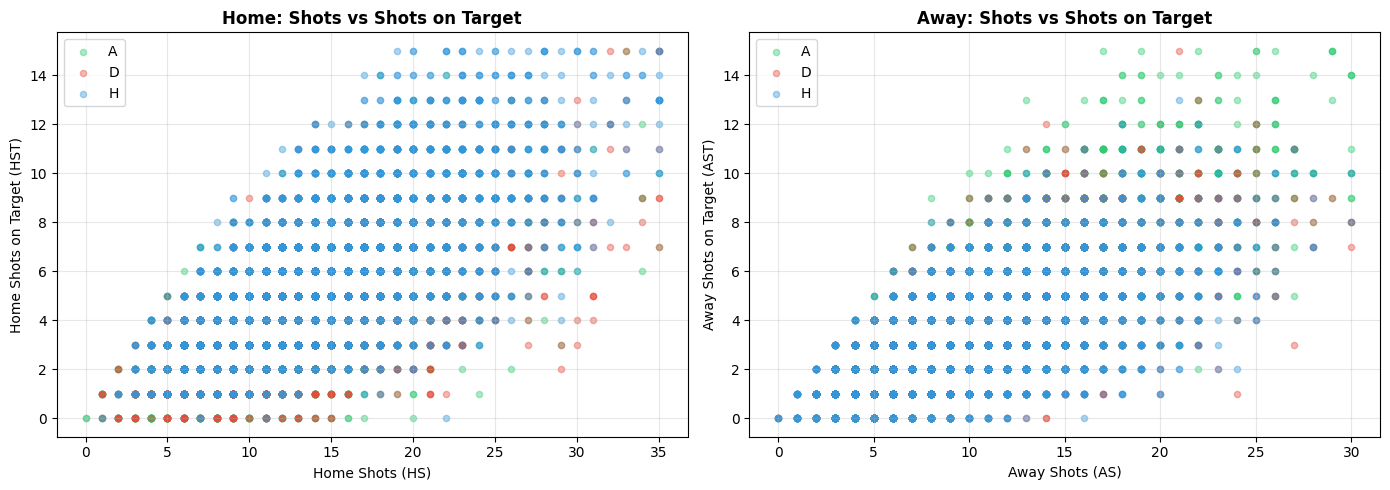

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (label, color) in enumerate(zip(target_names, colors)):
    mask = (y == sorted(target_counts.index)[i])
    axes[0].scatter(df.loc[mask, "HS"], df.loc[mask, "HST"],
                    alpha=0.4, label=label, color=color, s=20)
axes[0].set_xlabel("Home Shots (HS)")
axes[0].set_ylabel("Home Shots on Target (HST)")
axes[0].set_title("Home: Shots vs Shots on Target", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

for i, (label, color) in enumerate(zip(target_names, colors)):
    mask = (y == sorted(target_counts.index)[i])
    axes[1].scatter(df.loc[mask, "AS"], df.loc[mask, "AST"],
                    alpha=0.4, label=label, color=color, s=20)
axes[1].set_xlabel("Away Shots (AS)")
axes[1].set_ylabel("Away Shots on Target (AST)")
axes[1].set_title("Away: Shots vs Shots on Target", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.8 EDA conclusions

  The data is moderately imbalanced — Home wins are the most common outcome, draws the rarest. Shots-on-target (HST/AST) correlate strongly with goals (~0.5+) and visibly separate winning from losing teams in boxplots. Bookmaker odds reflect those imbalances. We will need to (i) handle imbalance with SMOTE on training data only, and (ii) standardize features before distance-based or linear models.



## 7. Hypothesis Testing

We test two intuitive hypotheses statistically before modelling.

### Hypothesis 1 — Home advantage exists

In [18]:
home_code = le_target.transform(["H"])[0]
away_code = le_target.transform(["A"])[0]

home_wins = (y == home_code).sum()
away_wins = (y == away_code).sum()
total = len(y)

print(f"Home wins: {home_wins} ({home_wins/total*100:.2f}%)")
print(f"Away wins: {away_wins} ({away_wins/total*100:.2f}%)")
print(f"Difference: {(home_wins-away_wins)/total*100:.2f} pp")

# Chi-square: does outcome distribution depend on the league?
contingency = pd.crosstab(df["League"], y)
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"\nChi-square (League vs Outcome): chi2={chi2:.4f}, p={p_value:.4e}, dof={dof}")
print("=> Home advantage holds and outcome distribution differs by league."
      if p_value < 0.05 else
      "=> No significant league effect.")


Home wins: 6390 (44.21%)
Away wins: 4463 (30.88%)
Difference: 13.33 pp

Chi-square (League vs Outcome): chi2=21.2879, p=1.6283e-03, dof=6
=> Home advantage holds and outcome distribution differs by league.


### Hypothesis 2 — Bookmaker odds are informative

In [19]:
print("Average B365 odds by realised outcome:")
for code_ in sorted(target_counts.index):
    mask = (y == code_)
    print(f"\n  {inv.get(code_)} (={code_}):")
    print(f"    B365H: {df.loc[mask,'B365H'].mean():.2f}")
    print(f"    B365D: {df.loc[mask,'B365D'].mean():.2f}")
    print(f"    B365A: {df.loc[mask,'B365A'].mean():.2f}")

groups = [df.loc[y == c, "B365H"].values for c in sorted(target_counts.index)]
F, p = f_oneway(*groups)
print(f"\nANOVA on B365H across outcomes: F={F:.4f}, p={p:.4e}")
print("=> Odds significantly differ by outcome (informative)."
      if p < 0.05 else "=> Odds do not significantly differ.")


Average B365 odds by realised outcome:

  A (=0):
    B365H: 3.88
    B365D: 3.93
    B365A: 2.96

  D (=1):
    B365H: 2.71
    B365D: 3.84
    B365A: 4.01

  H (=2):
    B365H: 2.13
    B365D: 4.39
    B365A: 5.96

ANOVA on B365H across outcomes: F=1212.1627, p=0.0000e+00
=> Odds significantly differ by outcome (informative).




Chi-square checks whether the outcome distribution depends on the league (categorical vs categorical). ANOVA compares the mean `B365H` across the three outcome groups: if odds carry information about the eventual outcome, group means must differ. p < 0.05 → reject H0.


## 8. ML Pipeline — split → scale → SMOTE

This is where the original notebook had bugs. The correct order is **strict**:

1. **Split first** — train_test_split with `stratify=y` to preserve class proportions.
2. **Scale on train only** — `StandardScaler.fit(X_train)`; the same scaler is *applied* to `X_test`. Fitting on the full data leaks information.
3. **SMOTE on train only** — synthetic oversampling must never see the test set, otherwise evaluation is optimistic.
4. **Same `X_train_resampled` is fed to all models** — so comparisons are fair.




In [20]:
# 1. Split first
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

# 2. Scale (fit only on train)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw),
                              columns=X.columns, index=X_train_raw.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_raw),
                              columns=X.columns, index=X_test_raw.index)

# 3. SMOTE on training data only
print("\nClass distribution before SMOTE (train):")
print(pd.Series(y_train_raw).value_counts(normalize=True).round(3))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_raw)

print("\nClass distribution after SMOTE (train):")
print(pd.Series(y_train_res).value_counts(normalize=True).round(3))

print(f"\nFinal training set: {X_train_res.shape}")
print(f"Final test set:     {X_test_scaled.shape}")


Train: (11564, 32), Test: (2891, 32)

Class distribution before SMOTE (train):
target
2    0.442
0    0.309
1    0.249
Name: proportion, dtype: float64

Class distribution after SMOTE (train):
target
2    0.333
0    0.333
1    0.333
Name: proportion, dtype: float64

Final training set: (15336, 32)
Final test set:     (2891, 32)


## 9. Model Training and Tuning

We train four classical models and tune them with cross-validation. They are chosen to cover a range of inductive biases:

| Model | Inductive bias | Why include it |
|---|---|---|
| Logistic Regression | linear, probabilistic | strong baseline; outputs calibrated probabilities |
| K-Nearest Neighbors | local, distance-based | captures local structure; sanity check |
| Decision Tree | non-linear, axis-aligned splits | interpretable; tells us which features split classes |
| Random Forest | ensemble of trees, low variance | usually the best of the four; gives feature importance |




### 9.1 Logistic Regression

In [21]:
print("=" * 60); print("Logistic Regression — RandomizedSearchCV"); print("=" * 60)

lr_params = {
    "C": np.logspace(-2, 2, 10),
    "solver": ["lbfgs", "liblinear"],
}
lr = LogisticRegression(max_iter=500, random_state=42)

search_lr = RandomizedSearchCV(lr, lr_params, n_iter=10, cv=3,
                               scoring="accuracy", n_jobs=-1,
                               random_state=42, verbose=0)
search_lr.fit(X_train_res, y_train_res)

lr_model = search_lr.best_estimator_
lr_pred  = lr_model.predict(X_test_scaled)
print(f"Best params: {search_lr.best_params_}")
print(f"Best CV score: {search_lr.best_score_:.4f}")


Logistic Regression — RandomizedSearchCV
Best params: {'solver': 'liblinear', 'C': np.float64(1.6681005372000592)}
Best CV score: 0.5936


### 9.2 K-Nearest Neighbors

In [22]:
print("=" * 60); print("K-Nearest Neighbors — GridSearchCV"); print("=" * 60)

knn_params = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights":     ["uniform", "distance"],
    "p":           [1, 2],   # 1 = Manhattan, 2 = Euclidean
}
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, knn_params, cv=3, scoring="accuracy",
                        n_jobs=-1, verbose=0)
grid_knn.fit(X_train_res, y_train_res)

knn_model = grid_knn.best_estimator_
knn_pred  = knn_model.predict(X_test_scaled)
print(f"Best params: {grid_knn.best_params_}")
print(f"Best CV score: {grid_knn.best_score_:.4f}")


K-Nearest Neighbors — GridSearchCV
Best params: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best CV score: 0.6886


### 9.3 Decision Tree

In [23]:
print("=" * 60); print("Decision Tree — GridSearchCV"); print("=" * 60)

dt_params = {
    "max_depth":         [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}
dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, dt_params, cv=5, scoring="accuracy",
                       n_jobs=-1, verbose=0)
grid_dt.fit(X_train_res, y_train_res)

dt_model = grid_dt.best_estimator_
dt_pred  = dt_model.predict(X_test_scaled)
print(f"Best params: {grid_dt.best_params_}")
print(f"Best CV score: {grid_dt.best_score_:.4f}")


Decision Tree — GridSearchCV
Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV score: 0.5643


### 9.4 Random Forest

In [24]:
print("=" * 60); print("Random Forest — GridSearchCV"); print("=" * 60)

rf_params = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [10, 15, 20],
    "min_samples_split": [5, 10],
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, rf_params, cv=5, scoring="accuracy",
                       n_jobs=-1, verbose=0)
grid_rf.fit(X_train_res, y_train_res)

rf_model = grid_rf.best_estimator_
rf_pred  = rf_model.predict(X_test_scaled)
print(f"Best params: {grid_rf.best_params_}")
print(f"Best CV score: {grid_rf.best_score_:.4f}")


Random Forest — GridSearchCV
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 0.6875


## 10. Evaluation

For each model we report Accuracy, weighted Precision, weighted Recall and weighted F1. We use **weighted F1** as the primary criterion because the classes are imbalanced and weighted-F1 takes class support into account.




In [25]:
models_predictions = {
    "Logistic Regression": lr_pred,
    "K-Nearest Neighbors": knn_pred,
    "Decision Tree":       dt_pred,
    "Random Forest":       rf_pred,
}

results = []
for name, pred in models_predictions.items():
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, pred, average="weighted", zero_division=0)
    results.append({"Model": name, "Accuracy": acc,
                    "Precision": prec, "Recall": rec, "F1-Score": f1})
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "=" * 60); print("SUMMARY TABLE"); print("=" * 60)
print(results_df.round(4).to_string(index=False))



Logistic Regression:
  Accuracy:  0.6202
  Precision: 0.6181
  Recall:    0.6202
  F1-Score:  0.6182

K-Nearest Neighbors:
  Accuracy:  0.4735
  Precision: 0.4922
  Recall:    0.4735
  F1-Score:  0.4809

Decision Tree:
  Accuracy:  0.5510
  Precision: 0.5542
  Recall:    0.5510
  F1-Score:  0.5526

Random Forest:
  Accuracy:  0.6143
  Precision: 0.5944
  Recall:    0.6143
  F1-Score:  0.5998

SUMMARY TABLE
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6202     0.6181  0.6202    0.6182
K-Nearest Neighbors    0.4735     0.4922  0.4735    0.4809
      Decision Tree    0.5510     0.5542  0.5510    0.5526
      Random Forest    0.6143     0.5944  0.6143    0.5998


### 10.1 Pick the best model

In [26]:
best_idx = results_df["F1-Score"].idxmax()
best_model_name = results_df.loc[best_idx, "Model"]
best_f1 = results_df.loc[best_idx, "F1-Score"]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print("=" * 60)

best_predictions = models_predictions[best_model_name]

models_dict = {
    "Logistic Regression": lr_model,
    "K-Nearest Neighbors": knn_model,
    "Decision Tree":       dt_model,
    "Random Forest":       rf_model,
}
best_model = models_dict[best_model_name]


BEST MODEL: Logistic Regression
F1-Score: 0.6182


### 10.2 Model comparison plot

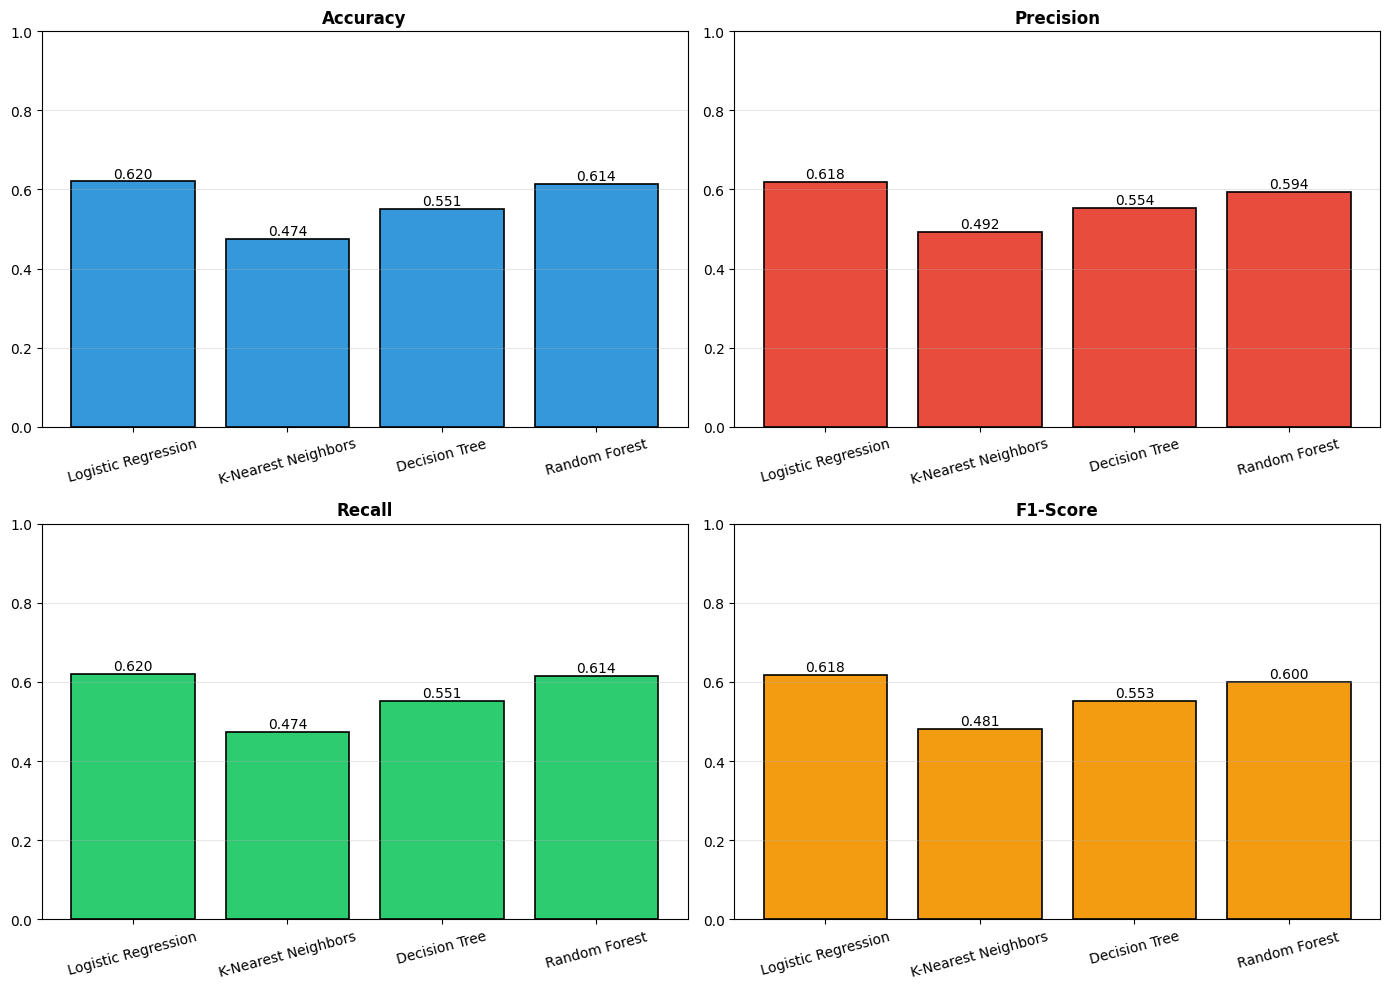

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors_m = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric]
    bars = ax.bar(results_df["Model"], values,
                  color=colors_m[idx], edgecolor="black", linewidth=1.2)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


### 10.3 Confusion matrix for the best model

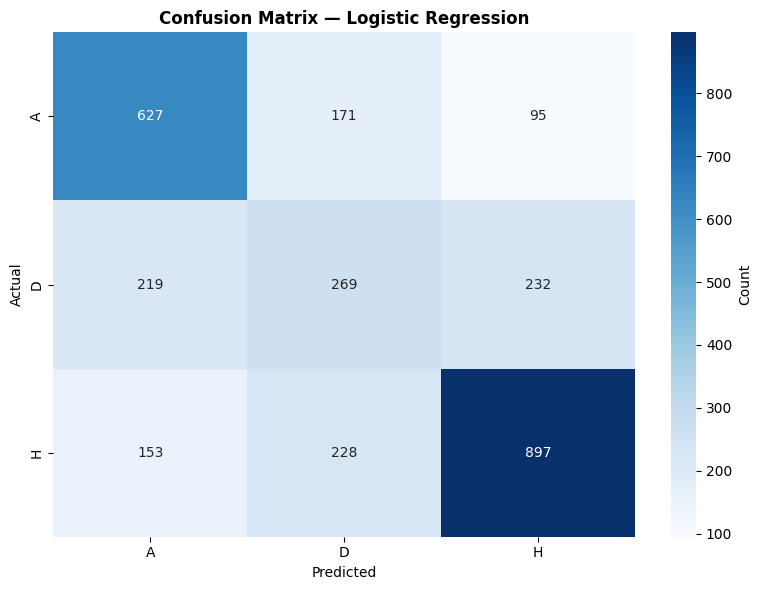


Classification report:
              precision    recall  f1-score   support

           A       0.63      0.70      0.66       893
           D       0.40      0.37      0.39       720
           H       0.73      0.70      0.72      1278

    accuracy                           0.62      2891
   macro avg       0.59      0.59      0.59      2891
weighted avg       0.62      0.62      0.62      2891



In [28]:
cm = confusion_matrix(y_test, best_predictions)
fig, ax = plt.subplots(figsize=(8, 6))
xtick = [inv.get(i) for i in sorted(np.unique(y_test))]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=xtick, yticklabels=xtick, ax=ax,
            cbar_kws={"label": "Count"})
ax.set_title(f"Confusion Matrix — {best_model_name}", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, best_predictions,
                            target_names=xtick, zero_division=0))


### 10.4 Feature importance (if Random Forest)

In [29]:
if isinstance(best_model, RandomForestClassifier):
    importances = best_model.feature_importances_
    feature_names = X.columns
    importance_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
                       .sort_values("Importance", ascending=False)
                       .head(15))

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(importance_df["Feature"], importance_df["Importance"],
            color="#3498db", edgecolor="black")
    ax.set_xlabel("Importance")
    ax.set_title("Top 15 Most Important Features", fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(importance_df.round(4).to_string(index=False))
else:
    print(f"Feature importance is shown only for Random Forest "
          f"(best model here is {best_model_name}).")


Feature importance is shown only for Random Forest (best model here is Logistic Regression).




## 11. Persist the trained pipeline

In [30]:
import pickle

bundle = {
    "model":       best_model,
    "model_name":  best_model_name,
    "scaler":      scaler,
    "features":    X.columns.tolist(),
    "le_target":   le_target,
    "le_team":     le_team,
}
with open("model_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("Saved model_bundle.pkl")


Saved model_bundle.pkl


## 12 Downloading

In [31]:
from google.colab import files
files.download("model_bundle.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>